# Simple Linear Regression — Python

This notebook reads salary data from a CSV file, visualizes the relationship between years of experience and salary, fits a simple linear regression model, overlays the fitted line on a scatter plot, and evaluates model performance.

**Model:**

$$\text{Salary} = \beta_0 + \beta_1 \cdot \text{YearsExperience} + \varepsilon$$

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

DATA_PATH = "../regression_data.csv"

Could not save font_manager cache Lock error: Matplotlib failed to acquire the following lock file:
    /users/PAS3421/teichmann22/.cache/matplotlib/fontlist-v3.11.0.json.matplotlib-lock
This maybe due to another process holding this lock file.  If you are sure no
other Matplotlib process is running, remove this file and try again.


## Load and inspect data

In [2]:
df = pd.read_csv(DATA_PATH)

print(f"Rows: {len(df)}, Columns: {len(df.columns)}")
df.head()

Rows: 10, Columns: 2


,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


In [3]:
df.describe()

,YearsExperience,Salary
count,10.000000,10.000000
mean,2.490000,49833.900000
std,1.018114,9519.789814
min,1.100000,37731.000000
25%,1.625000,40799.500000
50%,2.550000,50325.000000
75%,3.150000,57052.250000
max,4.000000,63218.000000


## Scatter plot

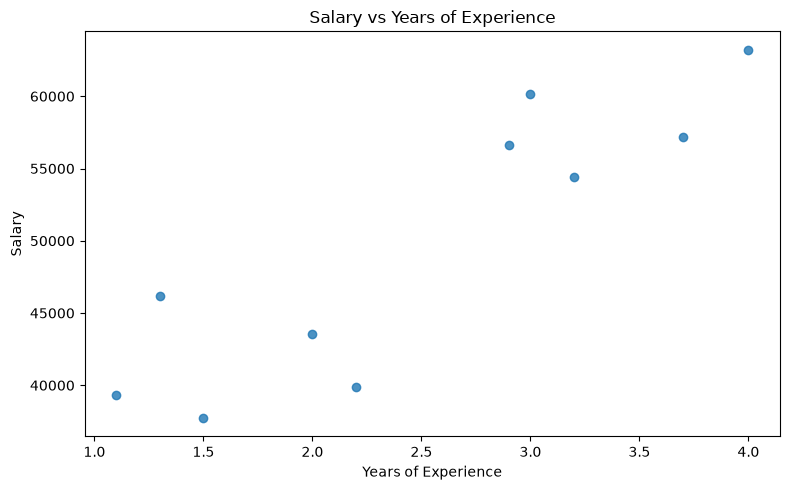

In [4]:
plt.figure(figsize=(8, 5))
plt.scatter(df["YearsExperience"], df["Salary"], alpha=0.8)
plt.title("Salary vs Years of Experience")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.tight_layout()
plt.show()

## Fit linear model

In [5]:
X = df[["YearsExperience"]]
y = df["Salary"]

model = LinearRegression()
model.fit(X, y)

intercept = model.intercept_
slope = model.coef_[0]

print(f"Intercept (beta_0): {intercept:,.2f}")
print(f"Slope (beta_1):     {slope:,.2f}")

Intercept (beta_0): 29,203.52
Slope (beta_1):     8,285.29


## Scatter plot with regression line

/users/PAS3421/teichmann22/.conda/envs/7030_class_2/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


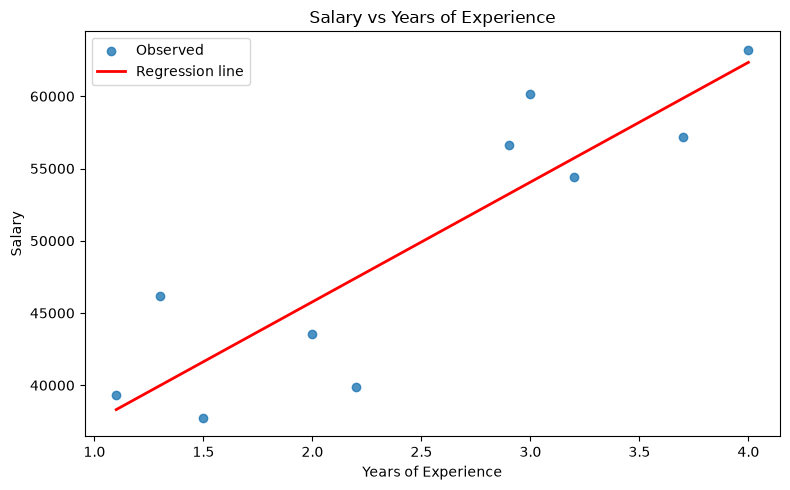

In [6]:
x_line = np.linspace(X["YearsExperience"].min(), X["YearsExperience"].max(), 100).reshape(-1, 1)
y_line = model.predict(x_line)

plt.figure(figsize=(8, 5))
plt.scatter(df["YearsExperience"], df["Salary"], alpha=0.8, label="Observed")
plt.plot(x_line, y_line, color="red", linewidth=2, label="Regression line")
plt.title("Salary vs Years of Experience")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.legend()
plt.tight_layout()
plt.show()

## Evaluate model

In [7]:
y_pred = model.predict(X)

r2 = r2_score(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))
mae = mean_absolute_error(y, y_pred)

print(f"R-squared: {r2:.4f}")
print(f"RMSE:      {rmse:,.2f}")
print(f"MAE:       {mae:,.2f}")

R-squared: 0.7852
RMSE:      4,186.15
MAE:       3,526.26
